# Hazard

In this notebook we read in Hazards from raster files, break down their properties and plot them.

CLIMADA describes hazards as one or more (and maybe thousands) of event footprints in a file. Each event in a Hazard object is a geospatial footprint – usually an event footprint (e.g. a historical flood depth reconstruction, or a month's simulated drought index) or a statistical summary – usually a return period footprint (e.g. the 10-year return period wind speed).

Every event has an ID and a frequency describing how often it occurs within the framework of the analysis (e.g. annual, or 1-in-100 year probability). Together these can describe a case study, a historical event set, a daily time series, a stochastic event set, or more. 

Each event footprint is defined on an underlying set of Centroids – an object containing a geodataframe of points, ensuring that all hazards are defined at the same locations (events can have zero or missing values).

Centroids are often a regular grid but don't have to be: they can be daily climate model output, or hazard interpolated to the locations of your exposures, or defined at the locations of weather stations, or on a variable resolution grid that gives more detail in more complex or more exposed areas. Usually these will be inferred from the data source, but sometimes you need to specify them.

Hazards are in the `climada.hazard` package's `Hazard` class and Centroids in the package's `Centroids` class.

Hazards are stored either as .hdf5 files, written and read with CLIMADA's own format, or (when the hazard is on a regular grid) as .tif raster files or in an xarray-compatible format (e.g. NetCDF, HDF5). In the case of a .tif file you will need to provide additional metadata when you read in the file (even IDs, event frequencies, etc).


## Hazards from raster files

Let's read in a raster file. You can provide a single .tif with one band for each event, or a separate .tifs file for each event. In this case we use a single file with a band for each year.

In this analysis we use a different hazard file for each crop type, since each crop has a different growing season and therefore experiences a different maximum drought intensity in a given year.

In [1]:
from climada.hazard import Hazard
from pathlib import Path

HAZARD_DIR = "../data/hazard/annual/"
HAZARD_FILES = {
    "maize": "ElSalvador_SPEI12_present_maize.tif",
    "beans": "ElSalvador_SPEI12_present_beans.tif",
    "sorghum": "ElSalvador_SPEI12_present_sorghum.tif",
}
haz_filepaths = {crop: Path(HAZARD_DIR) / filename for crop, filename in HAZARD_FILES.items()}

### Setting event frequencies

Since we're reading from raster files, we need to provide additional metadata that's not contained in the .tif. This includes information on the event frequency.

The drought hazard data we use contains annual drought metrics for SPEI12 for each crop's growing season. Therefore the frequency of each event, from a probabilistic perspective, is 1 / (number of years of data).

**Note:** This assumes that drought years are uncorrelated, which is likely not true – a more nuanced approach to drought modelling would account for this.

In [2]:
import copy
import numpy as np
from climada.hazard import Hazard

n_years_data = 54   # 1972 to 2025 inclusive
event_frequency = 1 / n_years_data   

# Read in the hazard data
haz_dict = {}

for crop, filepath in haz_filepaths.items():
    haz = Hazard.from_raster(
        files_intensity = filepath,
        band=list(np.arange(n_years_data) + 1),
        attrs={
            'unit': 'SPEI',   # as an index the SPEI has no units – so we can specify this or an empty string, as long as it is consistent with the Entity file Impact Functions
            'event_name': [str(year) for year in np.arange(1972, 2026)],     # We can optionally name the events
            'frequency': np.full(n_years_data, event_frequency)              # Define the frequency of each event
        },
        haz_type='DR',        # Specify that this is drought data
        window=None,          # Only read a window from the raster datasets, provided as a rasterio.windows.Windows object 
        geometry=None,        # Only read within a given geometry, provided as a list of shapely.geometry objects
    )

    haz.intensity[haz.intensity > 0] = 0     # Set positive drought indices to zero to speed up calculation 
    haz_dict[crop] = copy.deepcopy(haz)

2026-06-01 18:29:46,372 - climada.util.coordinates - INFO - Reading ../data/hazard/annual/ElSalvador_SPEI12_present_maize.tif
2026-06-01 18:29:46,394 - climada.util.coordinates - INFO - Reading ../data/hazard/annual/ElSalvador_SPEI12_present_maize.tif
2026-06-01 18:29:46,402 - climada.util.coordinates - INFO - Reading ../data/hazard/annual/ElSalvador_SPEI12_present_beans.tif
2026-06-01 18:29:46,408 - climada.util.coordinates - INFO - Reading ../data/hazard/annual/ElSalvador_SPEI12_present_beans.tif
2026-06-01 18:29:46,415 - climada.util.coordinates - INFO - Reading ../data/hazard/annual/ElSalvador_SPEI12_present_sorghum.tif
2026-06-01 18:29:46,420 - climada.util.coordinates - INFO - Reading ../data/hazard/annual/ElSalvador_SPEI12_present_sorghum.tif


In [3]:
# Print some properties of the hazards
# Some of these properties are common to all hazards, so we only print them for maize

haz = haz_dict["maize"]
print("Hazard properties:")
print(f"Number of events: {haz.size}")
print(f"Number of centroids at which the hazard is defined: {haz.centroids.size}")
print(f"Hazard CRS: {haz.centroids.crs}")
print(f"Latitude range: ({haz.centroids.lat.min():.2f}, {haz.centroids.lat.max():.2f})")
print(f"Longitude range: ({haz.centroids.lon.min():.2f}, {haz.centroids.lon.max():.2f})")
print(f"Event frequencies ({haz.frequency_unit}): {haz.frequency}")
print(f"Minimum fraction: {haz.fraction.min()}")
print(f"Maximum fraction: {haz.fraction.max()}")
for crop, haz_crop in haz_dict.items():
    print(f"Minimum intensity for {crop}: {haz_crop.intensity.min()} {haz.units}")
for crop, haz_crop in haz_dict.items():
    print(f"Maximum intensity for {crop}: {haz_crop.intensity.max()} {haz.units}")

Hazard properties:
Number of events: 54
Number of centroids at which the hazard is defined: 15
Hazard CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Latitude range: (13.25, 14.25)
Longitude range: (-89.75, -87.75)
Event frequencies (1/year): [0.01851852 0.01851852 0.01851852 0.01851852 0.01851852 0.01851852
 0.01851852 0.01851852 0.01851852 0.01851852 0.01851852 0.01851852
 0.01851852 0.01851852 0.01851852 0.01851852 0.01851852 0.01851852
 0.01851852 0.01851852 0.01851852 0.01851852 0.01851852 0.01851852
 0.01851852 0.01851852 0.01851852 0.01851852 0.01851852 0.01851852
 0.01851852 0.01851852 0.01851852 0.01851852 0.01851852 0.01851852
 0.01851852 0.01851852 0.01851852 0.01851852 0.01851852 0.01851852
 0.01851852 0.01851852 0.018

CLIMADA calculations are more efficient when parts of the Hazard that don't cause impacts are set to zero, because of the way it uses sparse matrices.

(This calculation is small, so it's not very important, but we do it anyway, we setting values of the SPEI index > 0 to equal zero anyway

In [4]:
import copy

haz_masked_dict = {}

for crop, haz in haz_dict.items():
    new_haz = copy.deepcopy(haz)
    new_haz.intensity[new_haz.intensity > 0] = 0
    haz_masked_dict[crop] = new_haz

**Note:** In the Starter Pack for Peru, we subset the Hazard to include only Centroids that have a hazard > 0. This is because centroids without hazard are unhelpful in the analysis (since the flood hazard shows street-level flooding, with building rooftops unaffected: we wanted to remove centroids corresponding to the rooftops). The flood footprint here is different, and zero-valued hazard is valuable to include, since it shows us locations that were _not_ flooded, which we want to know.

## Plotting hazards

We can visualise hazards using methods in the `Hazard` class. This drought hazard is defined on an underlying regular grid.

When we use the `Hazard.plot_intensity` method, we can call it with the `event` parameter set to an event ID (to plot individual events) or set to zero, (to plot the highest intensity value across all events).

This 'maximum intensity' plot doesn't work for SPEI, where stronger droughts have large _negative_ values. The easiest way to visualize the most intense event, then, is briefly to copy the Hazard and multiply the intensity by -1, so that stronger droughts have larger positive values:

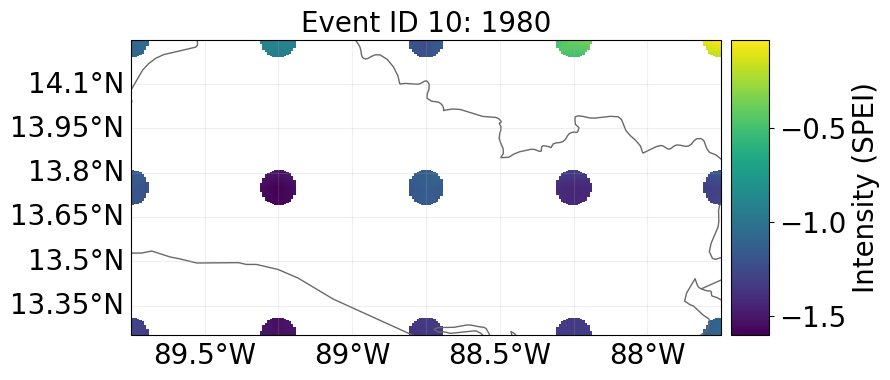

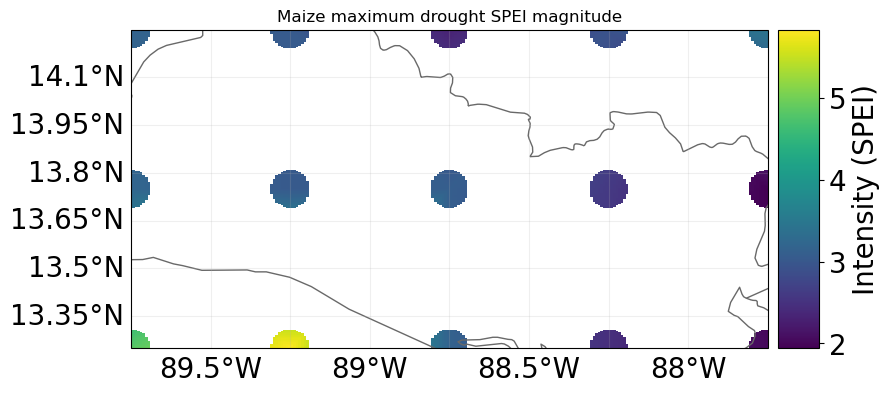

In [5]:
%matplotlib inline
from matplotlib import pyplot as plt

# Plot an individual event
_ = haz_dict["maize"].plot_intensity(event=10)

haz_inverted = copy.deepcopy(haz_dict["maize"])
haz_inverted.intensity = -haz_inverted.intensity
axis = haz_inverted.plot_intensity(event=0)
_ = axis.set_title("Maize maximum drought SPEI magnitude")

We can also plot the hazard values at individual centroids:

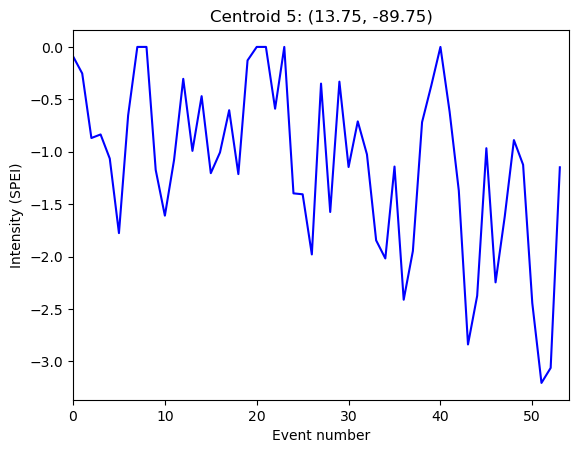

In [6]:
# Plot unmasked hazard time series
_ = haz_dict["maize"].plot_intensity(centr=5)

## Hazard object structure

The Hazard is defined through a few key properties:
- `centroids`: a CLIMADA Centroids object, which specifies the geographic points on which the hazard's events are all defined
- `intensity`: a sparse matrix, with dimensions (number of events) x (number of centroids), specifying the intensity of the hazard for each location and each event. (A sparse matrix is an efficient way to store matrices where many entries might be zero, which is the case for many hazards, including floods)
- `fraction`: another sparse matrix with the same dimensions, this time specifying the fraction of the assets affected by each event at each location. In this study we assume that all exposures are affected, so this matrix isn't required.
- `frequency`: an array giving the probabilistic frequency of each event. We defined these above

The underlying centroids can be visualized:

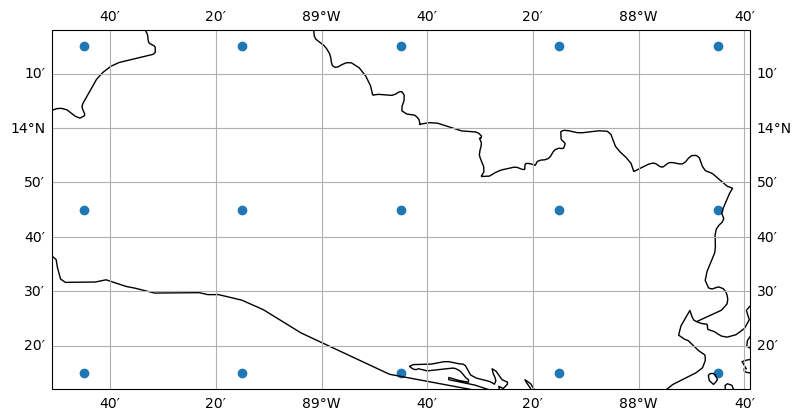

In [7]:
_ = haz_dict["maize"].centroids.plot()